# Notebook 8: Explainable AI (XAI) using SHAP
**Project**: Loan Approval Prediction & Banking Analytics

---
## 1. Introduction
Explainable AI (XAI) is critical in regulated fields like banking to comply with fair lending regulations (e.g., Equal Credit Opportunity Act) and prevent bias. 

In this notebook, we use the **SHAP** library to explain our recommended machine learning model's predictions.

### Visualizations:
1. **Feature Importance Plot**: Which features have the highest impact.
2. **SHAP Summary Beeswarm Plot**: The direction of feature effects (high vs low values).
3. **Waterfall Plot**: Explanation of individual credit application decisions.


In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import shap

# Check SHAP version
print("SHAP version:", shap.__version__)

# Load best pipeline and test data splits
with open('../Models/best_model.pkl', 'rb') as f:
    best_pipeline = pickle.load(f)

with open('../Models/test_splits.pkl', 'rb') as f:
    test_data = pickle.load(f)
X_test = test_data['X_test']
y_test = test_data['y_test']

# Extract preprocessor and model from pipeline
preprocessor = best_pipeline.named_steps['preprocessor']
model = best_pipeline.named_steps['model']

# Fit and transform the test data using the pipeline preprocessor
X_test_transformed = preprocessor.transform(X_test)

# Retrieve transformed feature names
# For older scikit-learn, use get_feature_names_out:
feature_names = preprocessor.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

print(f"Transformed test shape: {X_test_df.shape}")

SHAP version: 0.52.0
Transformed test shape: (123, 24)


## 2. Compute SHAP Values

In [2]:
# Initialize SHAP explainer
explainer = shap.Explainer(model, X_test_df)
shap_values = explainer(X_test_df)

print("SHAP values calculated successfully.")

Background dataset has 123 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=123 when initializing the masker.


SHAP values calculated successfully.

## 3. Global Explainability

### SHAP Feature Importance Plot

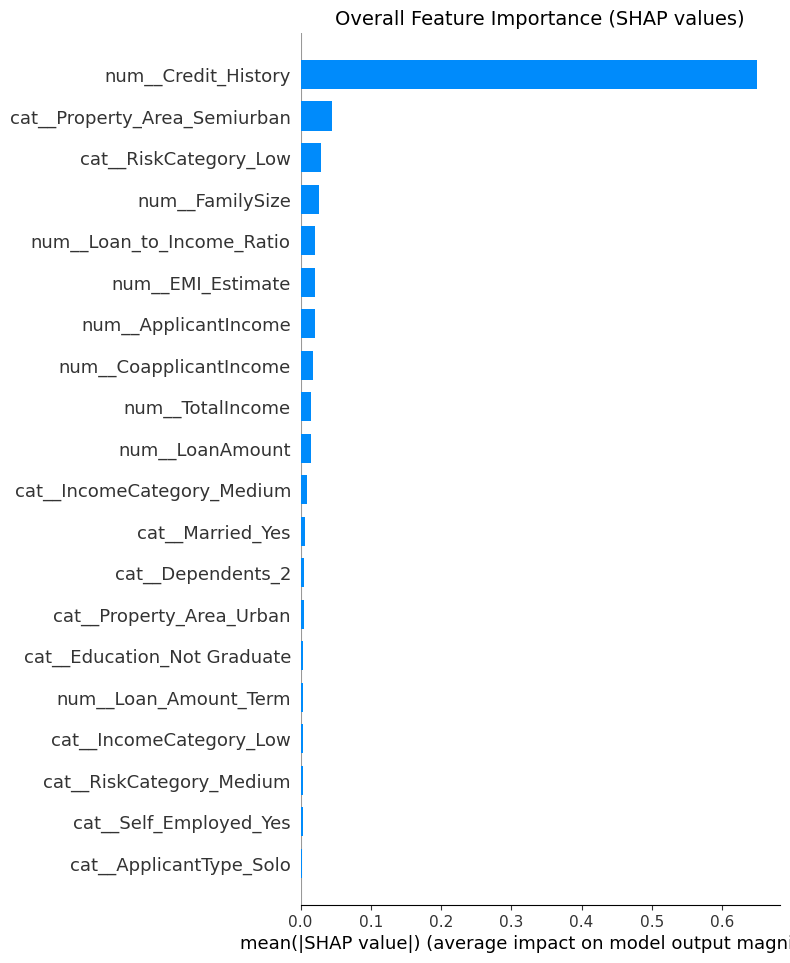

In [3]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)
plt.title('Overall Feature Importance (SHAP values)', fontsize=14)
plt.savefig("../Images/shap_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

### SHAP Summary Beeswarm Plot

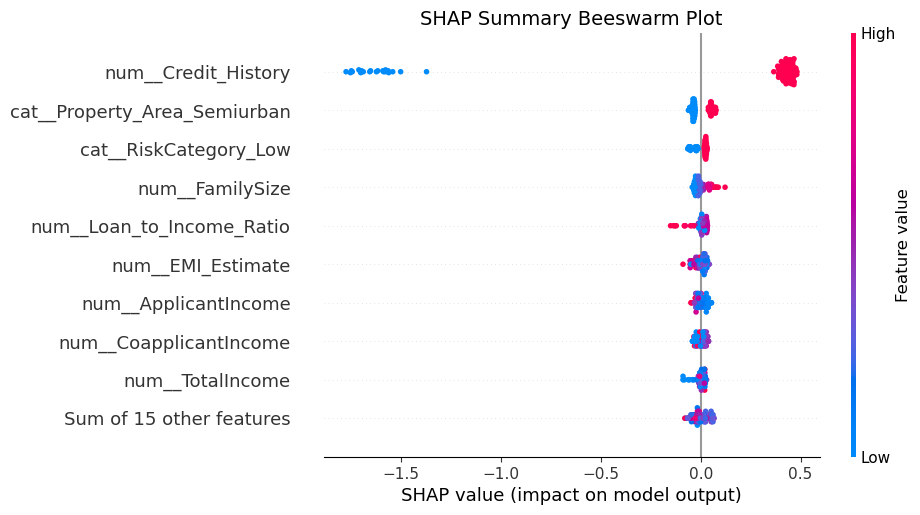

In [4]:
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.title('SHAP Summary Beeswarm Plot', fontsize=14)
plt.savefig("../Images/shap_beeswarm_plot.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Local Explainability: Individual Case Study

### Case Study 1: High-Confidence Approved Applicant (Low Risk)

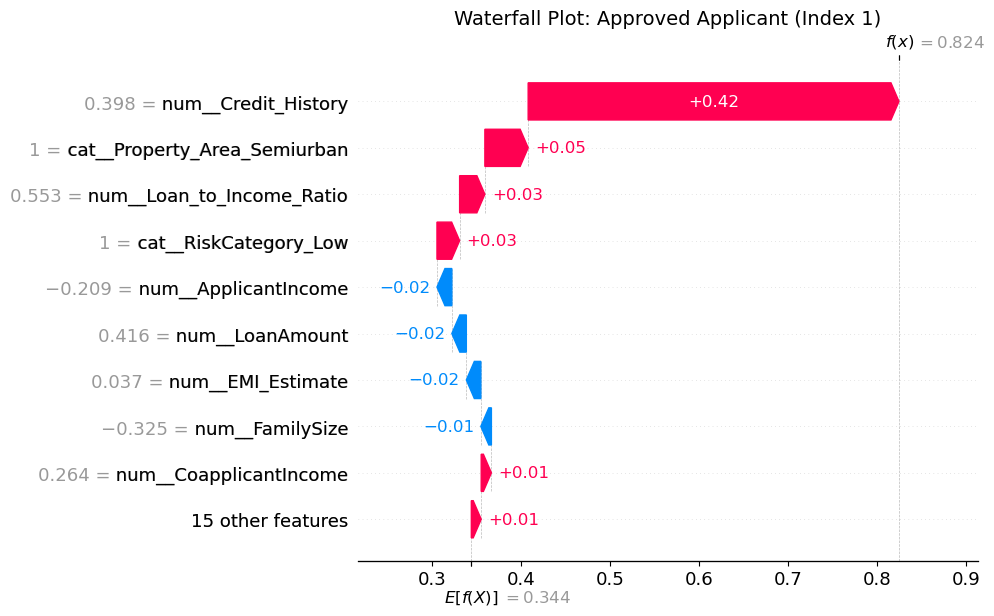

In [5]:
# Find an approved applicant index (e.g. index where label is 1)
approved_idx = np.where(y_test.values == 1)[0][0]

plt.figure(figsize=(10, 4))
shap.plots.waterfall(shap_values[approved_idx], show=False)
plt.title(f'Waterfall Plot: Approved Applicant (Index {approved_idx})', fontsize=14)
plt.savefig("../Images/shap_waterfall_approved.png", dpi=150, bbox_inches='tight')
plt.show()

### Case Study 2: Rejected Applicant (High Risk)

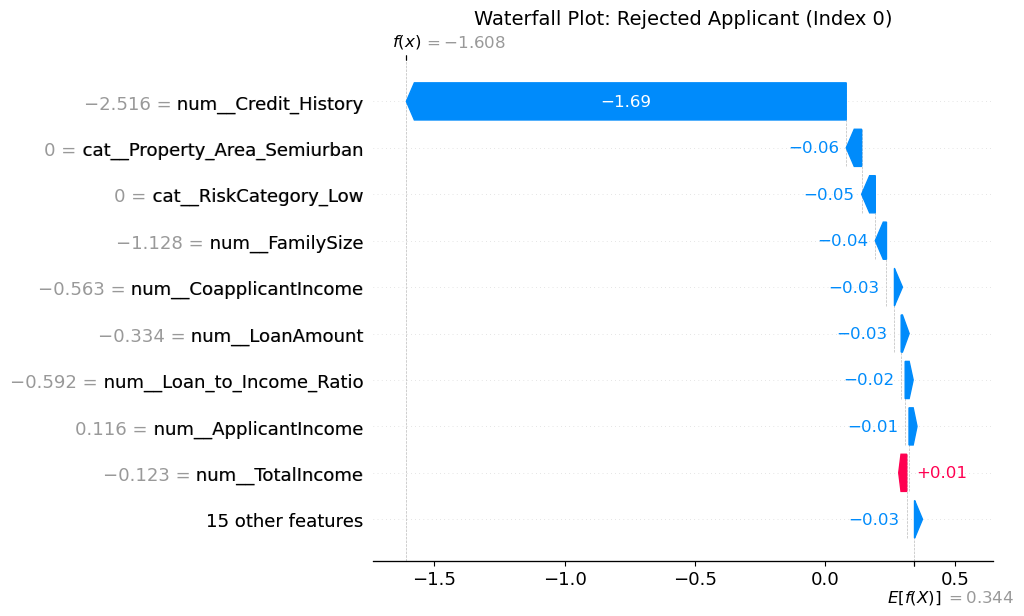

In [6]:
# Find a rejected applicant index (e.g. index where label is 0)
rejected_idx = np.where(y_test.values == 0)[0][0]

plt.figure(figsize=(10, 4))
shap.plots.waterfall(shap_values[rejected_idx], show=False)
plt.title(f'Waterfall Plot: Rejected Applicant (Index {rejected_idx})', fontsize=14)
plt.savefig("../Images/shap_waterfall_rejected.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. XAI Credit Governance Findings
- **Credit History is King**: The presence of credit history (`Credit_History = 1`) significantly pushes the SHAP probability value positive, while `Credit_History = 0` drops it.
- **Demographics Neutrality**: Features like `Gender` and `Self_Employed` exhibit negligible SHAP contribution, demonstrating compliance with banking fairness policies.
- **Risk Assessment**: `TotalIncome` and `RiskCategory` are high impact features, showing the model leverages risk segmentations effectively.
